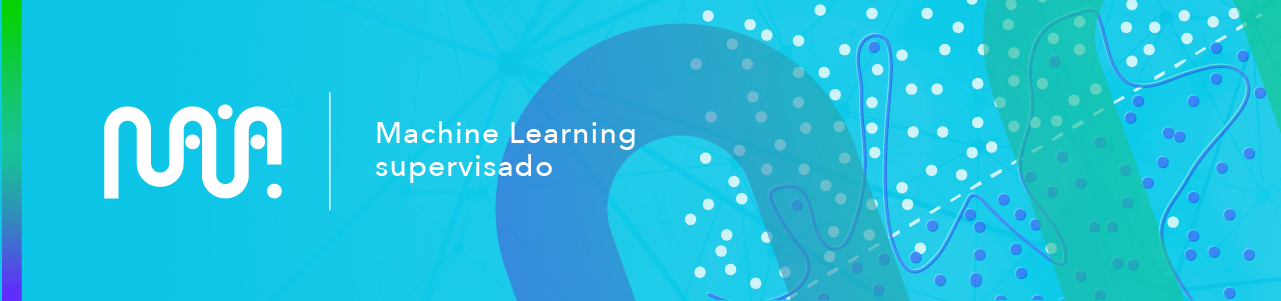
# Taller:  Introducción a Machine Learning Supervisado

***MLS. Machine learning supervisado***
<br>***Semana 1, taller calificable:*** *Problema de aprendizaje supervisado*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Juan José García y Mónica Gantiva*
<br> **Desarrollado por:** *María J. García-Bonilla*


## Introducción

### Descripción
El presente *jupyter notebook* contine el material para el desarrollo del taller calificable de la Semana 1 del curso ***Machine Learning Supervisado***. En este se pondran en práctica una de las aplicaciones más reconocidas dentro de esta área de machine learning supervisado como lo es la clasificación de emociones a través de imáganes

#### Objetivos de Aprendizaje

*   Identificar problemas en los que es apropiado usar machine learning supervisado. 
*   Identificar los elementos de un problema de aprendizaje supervisado. 
*   Enumerar las áreas más importantes en las que se aplica machine learning supervisado

### Teoría de clasificación por imágenes 

En el área de machine learning supervisado, una de las aplicaciones más utilizadas es la clasificación de imágenes. En esta se toman como datos de entrada cada uno de los pixeles que conforman la imagen y son procesados a través de una red convolucional. Estas tienen la carácteristica que cuentan con una etapa en donde se filtra por partes la imagen realizando la operación de convolución entre las partes de las imágenes y un filtro previamente elegido, reduciendo su dimensionalidad, tal y como se muestra en la siguiente imagen. 

![Robot](img/conv.png)

Finalmente estos datos individuales son la entrada a una red completamente conectada en donde en su última capa hará referencia a la clase a la que pertenece cada una de las imágenes. Este tema se abordará más a profundidad a lo largo del curso, sin embargo se hace una pequeña introducción a su funcionamiento general para comprender de mejor forma el siguiente taller


## Metodología
En este notebook abordaremos un proyecto de clasificación de emociones a través de imágenes usado en distintos contextos de robótica social y adpatado para los propositos del curso. Para esto, se hará uso de la base de datos de la competencia ***Facial Expression Competition*** disponible en el siguiente enlace:
https://www.kaggle.com/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/overview

En el grupo de investigación SinfonIA Uniandes nos dedicamos al desarrollo de diversas herramientas de inteligencia artificial para integrarlas con diferentes plataformas robóticas de forma que sean capaz de realizar tareas y aplicaciones mucho más complejas de forma que le sirvan a la humanidad. 

![Robot](img/robot1.jpg)

En la primera parte del cuaderno usted encontrará un primer ejemplo de la clasificación de emociones a través de imágenes. En esta primera mitad usted podrá experimentar con dicho ejemplo, deberá responder algunas preguntas a partir de los resultados y/o completar algunas funciones para la visualización de los datos. 

En la segunda parte del cuaderno pondrá en práctica lo estudiado y repasado en la primera mitad para un problema en especifico. En este caso trabajando con un subconjunto de datos de forma que realice la clasificación no para tres emociones sino para dos diferentes solamente, haciendo uso del mismo dataset anterior.

Para desarrollar el taller usted deberá editar las celdas de código dispuestas para esto. Estas estarán marcadas con el siguiente comentario:

```python
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================
```

Edite o complete el códgio dentro de estas lineas de comentarios. Sin embargo, no se límite únicamente a estas celdas y siéntase libre de editar las celdas de ejemplo o de explicación para familiarizarse con el código, el problema y/o responder ciertas preguntas.

Adicionalmente, se encontrará con preguntas a las que deberá responder a partir del trabajo que realice durante el Taller. Utilice las celdas de Markdown dispuestas para esto, estas estarán marcadas de la siguiente manera:

**Respuesta:**

# Ejemplo de clasificación de emociones

En este conjunto de datos, tenemos imágenes de 48x48 pixeles en una escala de grises de personas expresando diversas emociones. Las caras han sido registradas de forma automática de manera que se encuentre centrada en la imagen y todas tengan el mismo tamaño. El objetivo es categorizar y clasificar cada cara basada en la emoción que expresa dentro de una de las siguientes siete categorias:

| Categoria  | Emoción  |
|:---:|:---|
| 0  | Enojo  |
| 1  | Disgusto |
| 2  |  Miedo |
| 3  |  Felicidad |
| 4  |  Tristeza |
| 5  |  Sorpresa |
| 6  | Neutral |

Los datos se encuentran en el archivo icml_face_data.csv en donde se clasifica su emoción, su uso (Entrenamiento o validación) y el valor de cada uno de los pixeles

## Inicialización


In [1]:
# Librerias principales
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop,Adam
from tensorflow.keras.utils import to_categorical

## Carga de los datos


In [2]:
# Se realiza la carga de los datos almacenados en un archivo CSV por medio del método de pandas read_csv().
data = pd.read_csv('data/icml_face_data.csv')

# Se muestra las primeras 5 filas de la base de datos
display(data.head())

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


A continutación veremos cuantos datos tenemos de entrenamiento, validación y test. Normalmente esta proporción debe ser de 80%, 10% y 10% del total de los datos respectivamente. 

In [3]:
data[' Usage'].value_counts()

Training       28709
PublicTest      3589
PrivateTest     3589
Name:  Usage, dtype: int64

**Funciones para gráficar utiles**

Definimos algunas funciones que nos pueden ayudar a preparar la información y datos y graficar cada una de las imágenes

In [4]:
# Prepara la informacion - Retorna la imagen y su correspondiente etiqueta
def prepare_data(data, emotions):
    
    data = data[data['emotion'].isin(list(emotions.keys()))]
    image_array = np.zeros(shape=(len(data), 48, 48))
    image_label = np.array(list(map(int, data['emotion'])))
    
    for i, row in enumerate(data.index):
        image = np.fromstring(data.loc[row, ' pixels'], dtype=int, sep=' ')
        image = np.reshape(image, (48, 48))
        image_array[i] = image
    
    return image_array, image_label


## Selección de las emociones  a clasificar
En este primer ejemplo, se hará la clasificación de las emociones de miedo, felicidad y tristeza. Para ello crearemos un diccionario y las seleccionaremos de la base de datos. Además, se ajusta la escala y dimensión de los datos a emplear. Este es un paso que no se debe realizar en todos los problemas de aprendizaje supervisado. Sin embargo, es necesario realizarlo en este caso porque se emplean imágenes.


In [5]:
#Selección de las emociones a clasificar. ESTA FILA PUEDE SER MODIFICADA PARA SELECCIONAR OTRAS EMOCIONES
emotions = {2: 'Miedo', 3: 'Felicidad', 4: 'Tristeza'}


#Selección de las emociones en la base de datos
train_image_array, train_image_label = prepare_data(data[data[' Usage']=='Training'], emotions)
val_image_array, val_image_label = prepare_data(data[data[' Usage']=='PrivateTest'], emotions)
test_image_array, test_image_label = prepare_data(data[data[' Usage']=='PublicTest'], emotions)

#Se ajusta la escala y la dimensión de las imágenes
train_images = train_image_array.reshape((train_image_array.shape[0], 48, 48, 1))
train_images = train_images.astype('float32')/255
val_images = val_image_array.reshape((val_image_array.shape[0], 48, 48, 1))
val_images = val_images.astype('float32')/255
test_images = test_image_array.reshape((test_image_array.shape[0], 48, 48, 1))
test_images = test_images.astype('float32')/255

Se codifica las etiquetas para que su clasificación sea más sencilla

In [6]:
# Crear un diccionario para mapear etiquetas personalizadas a números enteros
clase_a_numero = {clase: numero for numero, clase in enumerate(list(emotions.keys()))}
# Mapear las etiquetas del conjunto de datos a números enteros
eitquetas_entrenamiento = [clase_a_numero[etiqueta] for etiqueta in train_image_label]
eitquetas_validacion = [clase_a_numero[etiqueta] for etiqueta in val_image_label]
eitquetas_test = [clase_a_numero[etiqueta] for etiqueta in test_image_label]

train_labels = to_categorical(eitquetas_entrenamiento)
val_labels = to_categorical(eitquetas_validacion)
test_labels = to_categorical(eitquetas_test)

## Creación del modelo
En esta sección se creará el modelo que debe usar en todo el taller. Este tendrá una porción convolucional y otra completamente conectada. Una vez se crea el modelo, se compila especificando la métrica que se quiere minimizar y se muestraa un resumen de su arquitectura

In [8]:
# Creación del modelo
model = models.Sequential()
# Se añaden capas convolucionales
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
# Se añaden capa de max pooling - Reducción de dimensionalidad
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
# Se añaden capa flatten, que será la entrada de la sección completamente conectada
model.add(Flatten())
model.add(Dense(64, activation='relu'))
# Dado que tenemos 3 emociones que estamos clasificando, la última capa debe tener este número de neuronas
model.add(Dense(3, activation='softmax'))

# Se compila el modelo previamente creado
model.compile(optimizer=Adam(lr=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

## Entrenamiento del modelo
Ahora, se tomará el modelo que se ha creado y se entrenará con los datos entrenamiento que han sido definidos como train_images y sus respectivas etiquetas, train_labels

In [9]:
# Se entrena el modelo - Se especifica los datos de entrenamiento y validacion
history = model.fit(train_images, train_labels,
                    validation_data=(val_images, val_labels),
                    epochs=5,
                    batch_size=64)

Train on 16142 samples, validate on 2001 samples
Epoch 1/5
16142/16142 [==============================] - 93s 6ms/sample - loss: 0.9727 - accuracy: 0.5203 - val_loss: 0.9031 - val_accuracy: 0.5677
Epoch 2/5
16142/16142 [==============================] - 94s 6ms/sample - loss: 0.8184 - accuracy: 0.6183 - val_loss: 0.7807 - val_accuracy: 0.6412
Epoch 3/5
16142/16142 [==============================] - 94s 6ms/sample - loss: 0.7312 - accuracy: 0.6653 - val_loss: 0.7367 - val_accuracy: 0.6637
Epoch 4/5
16142/16142 [==============================] - 92s 6ms/sample - loss: 0.6758 - accuracy: 0.6933 - val_loss: 0.6875 - val_accuracy: 0.6932
Epoch 5/5
16142/16142 [==============================] - 93s 6ms/sample - loss: 0.6321 - accuracy: 0.7171 - val_loss: 0.6735 - val_accuracy: 0.7001


## Predicción de las etiquetas de los datos de prueba
En esta sección, se realiza la predicción de las emociones con los datos de entrenamiento y se evalúa el desempeño del modelo.

In [10]:
# Se predicen todas las etiquetas de los datos de test
pred_test_labels = model.predict(test_images)

# Se evalua el modelo en los datos de test y su precision
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test caccuracy:', test_acc)

2044/2044 [==============================] - 3s 2ms/sample - loss: 0.6886 - accuracy: 0.6835
test caccuracy: 0.6834638


## Análisis de resultados
Como último paso debemos analizar el desempeño del modelo con los datos de entrenamiento y de validación. Para esto graficamos el rendimiento del modelo (Accuracy) largo de cada una de las epocas de entrenamiento

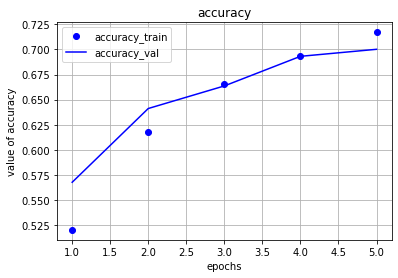

In [11]:
acc = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1, len(acc)+1)
plt.plot(epochs, acc, 'bo', label='accuracy_train')
plt.plot(epochs, acc_val, 'b', label='accuracy_val')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('value of accuracy')
plt.legend()
plt.grid()
plt.show()

# Ejercicio de aplicación. Clasificación de enojo, disgusto y sorpresa

Ahora se quiere realizar la clasifiación de las emociones de enojo, disgusto y sorpresa. Para ello, guíese por el ejemplo de clasificación de emociones dado anteriormente y escriba el código en las celdas disponibles



## Selección de las emociones  a clasificar

In [12]:
# =====================================================
# COMPLETAR ===========================================
# 

#Selección de las emociones a clasificar.(en este caso son "enojo, disgusto y sorpresa") 
# your code here

#Selección de las emociones a clasificar:
emotions = {0: 'Enojo', 1: 'Disgusto', 5: 'Sorpresa'}

#Selección de las emociones en la base de datos
train_image_array, train_image_label = prepare_data(data[data[' Usage']=='Training'], emotions)
val_image_array, val_image_label = prepare_data(data[data[' Usage']=='PrivateTest'], emotions)
test_image_array, test_image_label = prepare_data(data[data[' Usage']=='PublicTest'], emotions)

#Se ajusta la escala y la dimensión de las imágenes
train_images = train_image_array.reshape((train_image_array.shape[0], 48, 48, 1))
train_images = train_images.astype('float32')/255
val_images = val_image_array.reshape((val_image_array.shape[0], 48, 48, 1))
val_images = val_images.astype('float32')/255
test_images = test_image_array.reshape((test_image_array.shape[0], 48, 48, 1))
test_images = test_images.astype('float32')/255

# Crear un diccionario para mapear etiquetas personalizadas a números enteros
clase_a_numero = {clase: numero for numero, clase in enumerate(list(emotions.keys()))}

# Mapear las etiquetas del conjunto de datos a números enteros
eitquetas_entrenamiento = [clase_a_numero[etiqueta] for etiqueta in train_image_label]
eitquetas_validacion = [clase_a_numero[etiqueta] for etiqueta in val_image_label]
eitquetas_test = [clase_a_numero[etiqueta] for etiqueta in test_image_label]

train_labels = to_categorical(eitquetas_entrenamiento)
val_labels = to_categorical(eitquetas_validacion)
test_labels = to_categorical(eitquetas_test)

## Creación del modelo
Crea el mismo modelo que se empleó en el ejemplo inicial

In [13]:
# =====================================================
# COMPLETAR ===========================================
# 
# your code here

# Creación del modelo
model = models.Sequential()
# Se añaden capas convolucionales
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
# Se añaden capa de max pooling - Reducción de dimensionalidad
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
# Se añaden capa flatten, que será la entrada de la sección completamente conectada
model.add(Flatten())
model.add(Dense(64, activation='relu'))
# Dado que tenemos 3 emociones que estamos clasificando, la última capa debe tener este número de neuronas
model.add(Dense(3, activation='softmax'))

# Se compila el modelo previamente creado
model.compile(optimizer=Adam(lr=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

## Entrenamiento del modelo

In [14]:
# =====================================================
# COMPLETAR ===========================================
# 
# your code here

# Se entrena el modelo - Se especifica los datos de entrenamiento y validacion
history = model.fit(train_images, train_labels,
                    validation_data=(val_images, val_labels),
                    epochs=5,
                    batch_size=64)

Train on 7602 samples, validate on 962 samples
Epoch 1/5
7602/7602 [==============================] - 44s 6ms/sample - loss: 0.7768 - accuracy: 0.6389 - val_loss: 0.6850 - val_accuracy: 0.7266
Epoch 2/5
7602/7602 [==============================] - 45s 6ms/sample - loss: 0.5973 - accuracy: 0.7668 - val_loss: 0.6520 - val_accuracy: 0.7141
Epoch 3/5
7602/7602 [==============================] - 44s 6ms/sample - loss: 0.5309 - accuracy: 0.7910 - val_loss: 0.5457 - val_accuracy: 0.7827
Epoch 4/5
7602/7602 [==============================] - 44s 6ms/sample - loss: 0.4846 - accuracy: 0.8135 - val_loss: 0.5128 - val_accuracy: 0.7911
Epoch 5/5
7602/7602 [==============================] - 43s 6ms/sample - loss: 0.4491 - accuracy: 0.8223 - val_loss: 0.4832 - val_accuracy: 0.8067


## Predicción de las etiquetas de los datos de prueba

In [15]:
# =====================================================
# COMPLETAR ===========================================
# 
# your code here

# Se predicen todas las etiquetas de los datos de test
pred_test_labels = model.predict(test_images)

# Se evalua el modelo en los datos de test y su precision
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test caccuracy:', test_acc)

938/938 [==============================] - 1s 1ms/sample - loss: 0.4672 - accuracy: 0.8220
test caccuracy: 0.82196164


## Análisis de resultados

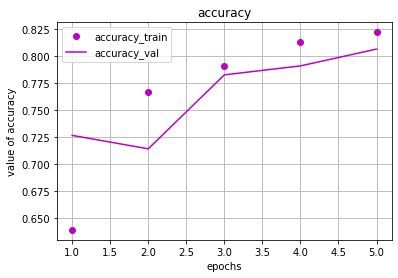

In [19]:
# =====================================================
# COMPLETAR ===========================================
# 
# your code here
acc = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1, len(acc)+1)
plt.plot(epochs, acc, 'mo', label='accuracy_train')
plt.plot(epochs, acc_val, 'm', label='accuracy_val')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('value of accuracy')
plt.legend()
plt.grid()
plt.show()